# 3D cell mask, poles, and edge regions

Combines two prior scripts into one pure-Python, 3D-aware pipeline:

- **`Xana Anlaysis.py`** (ImageJ macro): normalize+average channels, threshold the largest cell object, skeletonize to find the two "pole" endpoints, then build pole-cap and membrane-edge regions. It's inherently 2D (a single flat ROI extruded across Z).
- **`Threshold_cells_and_define_edge_ColoRect.ipynb`**: file-pairing pattern for separate per-channel TIFF Z-stacks (grouping files by shared basename), a slower background-subtraction (`remove_BKG`, Gaussian blur sized to the image) cell-mask approach, and the geodesic (`MCP_Geometric`) skeleton-distance technique reused below.

This notebook:
1. Loads separate per-channel TIFF Z-stacks using the same grouping idea as the ColoRect notebook, generalized to any number of channels.
2. Builds a true **3D** cell mask: Otsu-threshold each Z slice independently, drop small out-of-focus bleed-through specks per slice (`remove_small_objects`), then keep the single largest 3D-connected object -- faster than `remove_BKG`'s per-slice Gaussian background subtraction.
3. Finds the two poles from the max-projected mask's skeleton (as in the macro), pruned to its single longest path and snapped out to the mask's true boundary -- used only as a rough (y, x) reference point per pole.
4. Builds each pole's "end cap" region **per Z slice**: find the point on that slice's own mask nearest the pole (the "anchor"), then cut with a straight perpendicular line at `pole_arc_length` pixels from the anchor. The cut direction is the **average of three estimates**: (a) this slice's own local skeleton (skeletonized + pruned just for that slice), (b) the flat, whole-cell master skeleton, and (c) the straight line from the anchor to the overall cell centroid. Blending smooths out the noise from relying on any single one of these alone, while still tracking the pole's real per-slice position and curvature.
5. Builds a per-slice membrane **edge** band: erode the slice mask inward, keep the outer ring, remove the pole regions, and remove a dilated version of the (max-projected) skeleton so only the true outer edge remains.

Analysis/measurement is deferred — this notebook only builds and visualizes the masks.

In [19]:
import os
import glob
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.ndimage import binary_erosion, binary_dilation, binary_opening, binary_closing, binary_fill_holes, convolve, distance_transform_edt
from scipy.spatial.distance import pdist, squareform
from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize, disk, ball, remove_small_objects
from skimage.measure import label, regionprops
from skimage.graph import MCP_Geometric
from skimage.transform import resize

try:
    import napari
except ImportError:
    napari = None

In [20]:
FolderOI = r"C:\Users\jszczerkowski\Documents\Xana\Colocalisation\Colo_20260707"

# Two separate output folders, both prefixed with the parent (data) folder's
# name, so they're self-identifying if copied/zipped elsewhere without their
# parent folder:
# - {prefix}_results: CSVs + summary graphs only -- the small, easy-to-send bundle.
# - {prefix}_RepImages: per-cell scatter overview PNGs, region QC PNGs, and 3D TIFFs -- heavier, kept separate.
folder_prefix = os.path.basename(os.path.normpath(FolderOI))
results_dir = os.path.join(FolderOI, f"{folder_prefix}_results")
rep_images_dir = os.path.join(FolderOI, f"{folder_prefix}_RepImages")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(rep_images_dir, exist_ok=True)

seg_channels = (0, 1, 2)    # channels averaged together to define the cell footprint (mirrors the macro's 3-channel merge)
min_size = 20000            # minimum voxel count for the cell mask (mirrors macro's Min_size)
open_iterations = 5         # per-slice binary_opening iterations when thresholding
min_slice_size = 10000      # per-Z-slice: drop connected components smaller than this (removes out-of-focus bleed-through specks) -- applied in build_cell_mask, before anything below sees the mask

pole_arc_length = 50             # pole "end cap" cutoff, in pixels measured along each slice's own local skeleton from its anchor
min_pole_component_size = 50     # per-slice: ignore the piece nearest the pole if it's smaller than this
pole_smooth_radius = 2           # 3D binary-closing radius (spherical) applied to the combined pole region, to smooth slice-to-slice jitter
edge_erode_radius = 10           # per-slice erosion radius used to carve out the membrane edge band
skeleton_dilate_radius = 10      # dilation radius around each slice's own local skeleton, excluded from the edge band -- set to 0 to disable this step entirely
cell_mask_erode_radius = None    # per-Z-slice erode+fill-holes cleanup of the mask, used *only* to define the edge band's "inside" reference (see build_edge_region) -- does NOT affect pole/end detection, which always uses the original mask. None/0 disables.

show_dapi_in_composite = False   # set True to include DAPI (dimmed grey) in the per-cell composite thumbnail; doesn't affect DAPI's exclusion from the actual intensity/colocalization stats
show_cell_plots = True           # display each cell's scatter overview inline (in addition to always saving it) -- set False once max_cells is large, to avoid a very long notebook output

In [21]:
_CHANNEL_FILE_RE = re.compile(r"_C(\d+)\.tif$", re.IGNORECASE)


def find_channel_file_groups(folder, pattern=_CHANNEL_FILE_RE):
    """Group per-channel TIFF files in `folder` by shared basename.

    Same idea as the ColoRect notebook's paired_files dict, generalized from
    a hardcoded C0/C1 pair to any number of channels.
    Returns {basename: {channel_index: filepath}}.
    """
    groups = defaultdict(dict)
    for f in glob.glob(os.path.join(folder, "*.tif")):
        m = pattern.search(f)  # match against the full path, not just the basename,
        if not m:              # so m.start() indexes correctly when we slice f below
            continue
        base = f[: m.start()]
        groups[base][int(m.group(1))] = f
    return groups


def load_channel_stack(file_group):
    """file_group: {channel_index: filepath}, each file a (Z, Y, X) TIFF.

    Loads and stacks them (sorted by channel index) into one (C, Z, Y, X) array.
    """
    channels = sorted(file_group)
    arrays = [tifffile.imread(file_group[c]) for c in channels]
    shapes = {a.shape for a in arrays}
    if len(shapes) != 1:
        raise ValueError(f"Channel arrays have mismatched shapes: {shapes}")
    return np.stack(arrays, axis=0)

In [22]:
def build_cell_mask(stack, seg_channels=(0, 1, 2), min_size=20000, open_iterations=5, min_slice_size=500):
    """Normalize the given channels by their own global max, average them,
    Otsu-threshold each Z slice independently, then keep the single largest
    3D-connected object (>= min_size voxels) as the cell.

    Faster than the background-subtraction approach in
    Threshold_cells_and_define_edge.ipynb's remove_BKG (Gaussian blur sized
    to the whole image, run per slice) -- same idea as Xana Anlaysis.py's
    normalize+average+threshold, just applied per Z slice instead of on one
    max projection, so the mask can vary in shape across Z.

    Per-slice out-of-focus bleed-through (fluorescence from a brighter Z
    plane leaking into a neighboring slice) can show up as a small blob
    disconnected from the main cell body within that one slice. Opening
    alone won't remove it -- it's not thin, just small and separate -- so
    each slice is also run through remove_small_objects to drop any
    connected component smaller than min_slice_size before the 3D
    largest-object step.
    """
    merged = np.zeros(stack.shape[1:], dtype=np.float32)  # (Z, Y, X)
    for c in seg_channels:
        chan = stack[c].astype(np.float32)
        m = chan.max()
        if m > 0:
            merged += chan / m
    merged /= len(seg_channels)

    mask3d = np.zeros(merged.shape, dtype=bool)
    for z in range(merged.shape[0]):
        plane = merged[z]
        if plane.max() <= 0:
            continue
        thresh = threshold_otsu(plane)
        opened = binary_opening(plane > thresh, iterations=open_iterations)
        mask3d[z] = remove_small_objects(opened, min_size=min_slice_size)

    labels3d = label(mask3d)
    candidates = [p for p in regionprops(labels3d) if p.area >= min_size]
    if not candidates:
        raise ValueError(f"No 3D object with volume >= {min_size} voxels found.")
    largest = max(candidates, key=lambda p: p.area)
    return labels3d == largest.label

In [23]:
_NEIGHBOR_KERNEL = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])


def _snap_to_mask_tip(mask2d, endpoint):
    """Skeleton endpoints sit on the medial axis, which is typically a few
    pixels short of the mask's actual boundary (especially for blunt/rounded
    cell ends). Push the point out to the mask pixel that extends furthest
    from the mask's centroid in the endpoint's direction -- the true tip.
    """
    ys, xs = np.nonzero(mask2d)
    cy, cx = ys.mean(), xs.mean()
    dy, dx = endpoint[0] - cy, endpoint[1] - cx
    norm = np.hypot(dy, dx)
    if norm == 0:
        return endpoint
    dy, dx = dy / norm, dx / norm
    projection = (ys - cy) * dy + (xs - cx) * dx
    idx = np.argmax(projection)
    return np.array([ys[idx], xs[idx]])


def prune_to_master_branch(skeleton2d):
    """Prune a (possibly branchy) skeleton down to its single longest path
    -- the "master branch" between its two most distant points -- so short
    side spurs from skeletonize() don't cause the nearest-skeleton-point
    search to jump between branches and produce unstable cut angles.

    Standard "tree diameter via double geodesic search" trick: from any
    skeleton pixel, the furthest reachable pixel (A) is guaranteed to be
    one end of the longest path; from A, the furthest reachable pixel (B)
    is the other end. Trace the path between them and keep only those
    pixels. Uses the same MCP_Geometric geodesic-distance technique as
    skeleton_distance_map / the ColoRect notebook's get_elongated_cells.
    """
    ys, xs = np.nonzero(skeleton2d)
    if len(ys) < 2:
        return skeleton2d.copy()

    cost_array = np.where(skeleton2d, 1, np.inf)

    mcp = MCP_Geometric(cost_array)
    costs, _ = mcp.find_costs([(ys[0], xs[0])])
    costs_at_skel = costs[ys, xs]
    point_a = (ys[np.argmax(np.where(np.isfinite(costs_at_skel), costs_at_skel, -1))],
               xs[np.argmax(np.where(np.isfinite(costs_at_skel), costs_at_skel, -1))])

    mcp = MCP_Geometric(cost_array)
    costs, _ = mcp.find_costs([point_a])
    costs_at_skel = costs[ys, xs]
    point_b = (ys[np.argmax(np.where(np.isfinite(costs_at_skel), costs_at_skel, -1))],
               xs[np.argmax(np.where(np.isfinite(costs_at_skel), costs_at_skel, -1))])

    path = mcp.traceback(point_b)
    pruned = np.zeros_like(skeleton2d)
    for y, x in path:
        pruned[y, x] = True
    return pruned


def skeleton_distance_map(skeleton2d, skel_endpoint):
    """Geodesic distance along `skeleton2d`, in pixels, from `skel_endpoint`
    (a point on the skeleton) to every other skeleton pixel. Off-skeleton
    pixels are unreachable (infinite cost). Same MCP_Geometric technique
    used in Threshold_cells_and_define_edge_ColoRect.ipynb's
    get_elongated_cells for geodesic skeleton-branch length.
    """
    cost_array = np.where(skeleton2d, 1, np.inf)
    mcp = MCP_Geometric(cost_array)
    costs, _ = mcp.find_costs([tuple(skel_endpoint)])
    return costs


def find_poles(mask3d):
    """Max-project the 3D cell mask, skeletonize it, prune it down to its
    master branch, and return the two (now unambiguous) skeleton endpoints
    that are furthest apart ("poles"), snapped out to the mask's actual
    boundary, plus the pruned 2D skeleton itself.

    These are only used as a rough (y, x) reference point per pole -- the
    actual per-Z cap regions are found independently on each slice by
    per_slice_pole_cap_region below, since the cell's true shape can drift
    or curve away from this flat, max-projected skeleton across Z.
    """
    mask2d = mask3d.any(axis=0)
    skeleton2d = prune_to_master_branch(skeletonize(mask2d))
    neighbor_count = convolve(skeleton2d.astype(int), _NEIGHBOR_KERNEL, mode="constant")
    endpoints = np.column_stack(np.nonzero(skeleton2d & (neighbor_count == 1)))
    if len(endpoints) < 2:
        raise ValueError("Need at least 2 skeleton endpoints to find poles.")
    dists = squareform(pdist(endpoints))
    i, j = np.unravel_index(np.argmax(dists), dists.shape)
    pole1 = _snap_to_mask_tip(mask2d, endpoints[i])
    pole2 = _snap_to_mask_tip(mask2d, endpoints[j])
    return pole1, pole2, skeleton2d


def _component_near_point(plane, point):
    """Label the 2D `plane` and return only the connected component nearest
    `point` (a (y, x) coordinate). Guards against a slice whose mask
    happens to be split into more than one piece contaminating the
    per-slice skeleton for this pole.
    """
    labeled = label(plane)
    if labeled.max() == 0:
        return plane
    py, px = point
    best = min(
        regionprops(labeled),
        key=lambda p: (p.centroid[0] - py) ** 2 + (p.centroid[1] - px) ** 2,
    )
    return labeled == best.label


def _unit(vec):
    """Normalize a 2-vector; returns the zero vector unchanged."""
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec


def _skeleton_target_direction(skeleton2d, anchor, arc_length):
    """Find the skeleton point nearest `anchor`, walk `arc_length` pixels
    along the skeleton (geodesically) from there, and return the unit
    direction from `anchor` to that target point. Returns None if
    `skeleton2d` is empty.
    """
    skel_ys, skel_xs = np.nonzero(skeleton2d)
    if skel_ys.size == 0:
        return None
    d = np.hypot(skel_ys - anchor[0], skel_xs - anchor[1])
    seed = (skel_ys[np.argmin(d)], skel_xs[np.argmin(d)])
    dist_along = skeleton_distance_map(skeleton2d, seed)
    skel_dists = dist_along[skel_ys, skel_xs]
    target_idx = np.argmin(np.abs(skel_dists - arc_length))
    target = np.array([skel_ys[target_idx], skel_xs[target_idx]], dtype=np.float64)
    return _unit(target - np.asarray(anchor, dtype=np.float64))


def per_slice_pole_cap_region(mask3d, pole, master_skeleton2d, arc_length=100, min_component_size=50):
    """For each Z slice: isolate the piece of that slice's mask nearest
    `pole` (already cleaned of small debris upstream -- see
    build_cell_mask's min_slice_size).

    All the per-slice work (skeletonizing, geodesic distance) happens on a
    small crop -- a padded bounding box around just this slice's component
    -- instead of the full frame. Real microscopy frames are much larger
    than the cell itself, so doing this at full-frame resolution was the
    main cost; cropping gives identical results (nothing outside the
    component's own footprint + a small pad margin can affect it) for a
    fraction of the work.

    The cut origin (the "anchor") is the local skeleton's nearest point to
    `pole`, snapped out to the component's own true boundary the same way
    find_poles snaps the flat pole -- otherwise the anchor sits on the
    recessed medial axis, short of the actual cell tip.

    The cut is a straight perpendicular line at distance `arc_length` from
    the anchor, along a direction blended from three estimates (each a
    unit vector, simply averaged and renormalized):

    1. This slice's own local skeleton: walk `arc_length` pixels along it
       from the (pre-snap) skeleton point nearest the pole.
    2. The flat, max-projected master skeleton (`master_skeleton2d` from
       find_poles): same walk, but along the whole-cell skeleton -- stable
       across Z since it doesn't change per slice.
    3. The straight line from the (snapped) anchor to the overall cell
       centroid.

    Blending these instead of relying on any single one smooths out the
    per-slice skeleton noise (source 1 alone) while still letting the cut
    track real local curvature (sources 2 and 3 alone wouldn't).

    Returns (region, points, skeleton_stack): points is the (z, y, x)
    array of each slice's (snapped) anchor point; skeleton_stack is the
    (Z, Y, X) bool stack of each slice's local skeleton -- both for
    QC/plotting.
    """
    mask2d = mask3d.any(axis=0)
    mask_ys, mask_xs = np.nonzero(mask2d)
    centroid = np.array([mask_ys.mean(), mask_xs.mean()])

    dir_master = _skeleton_target_direction(master_skeleton2d, pole, arc_length)
    crop_pad = 2

    region = np.zeros_like(mask3d)
    skeleton_stack = np.zeros_like(mask3d)
    points = []
    for z in range(mask3d.shape[0]):
        plane = mask3d[z]
        if not plane.any():
            continue

        component = _component_near_point(plane, pole)
        ys_full, xs_full = np.nonzero(component)
        if ys_full.size < min_component_size:
            continue

        y0 = max(int(ys_full.min()) - crop_pad, 0)
        y1 = min(int(ys_full.max()) + crop_pad + 1, component.shape[0])
        x0 = max(int(xs_full.min()) - crop_pad, 0)
        x1 = min(int(xs_full.max()) + crop_pad + 1, component.shape[1])
        component_crop = component[y0:y1, x0:x1]
        pole_crop = (pole[0] - y0, pole[1] - x0)

        skeleton_crop = prune_to_master_branch(skeletonize(component_crop))
        skeleton_stack[z, y0:y1, x0:x1] = skeleton_crop
        skel_ys, skel_xs = np.nonzero(skeleton_crop)
        if skel_ys.size == 0:
            continue

        d_to_pole = np.hypot(skel_ys - pole_crop[0], skel_xs - pole_crop[1])
        skel_anchor_crop = np.array(
            [skel_ys[np.argmin(d_to_pole)], skel_xs[np.argmin(d_to_pole)]], dtype=np.float64,
        )
        anchor_crop = _snap_to_mask_tip(component_crop, skel_anchor_crop).astype(np.float64)
        anchor = anchor_crop + np.array([y0, x0], dtype=np.float64)
        points.append((z, anchor[0], anchor[1]))

        dir_local = _skeleton_target_direction(skeleton_crop, skel_anchor_crop, arc_length)
        dir_centroid = _unit(centroid - anchor)

        candidates = [d for d in (dir_local, dir_master, dir_centroid) if d is not None]
        direction = _unit(np.sum(candidates, axis=0))
        if np.linalg.norm(direction) == 0:
            region[z] = component
            continue

        coords = np.column_stack([ys_full, xs_full]).astype(np.float64)
        t = (coords - anchor) @ direction
        keep = t <= arc_length
        cap = np.zeros_like(component)
        cap[ys_full[keep], xs_full[keep]] = True
        region[z] = cap

    points = np.array(points) if points else np.empty((0, 3), dtype=float)
    return region, points, skeleton_stack

In [24]:
def smooth_region_3d(region3d, radius=2, clip_to=None):
    """3D binary closing (dilate then erode) with a spherical structuring
    element, to smooth per-slice inconsistencies in a 3D region mask into a
    coherent shape rather than a stack of independently-cut slices.

    binary_closing's erosion step treats anything past the array boundary
    as background (border_value=0), so without padding, real content
    sitting right at the first/last Z slice looks like it has "missing"
    neighbors beyond the stack and gets spuriously eroded away -- even
    though nothing is actually wrong there, the stack just ends. Padding
    along Z with edge-replication before closing (and cropping back after)
    avoids that.

    Closing can also bulge slightly past the original boundary during the
    dilation step; if `clip_to` (e.g. the cell mask) is given, the result
    is intersected back with it so the smoothed region never extends
    outside the actual cell.
    """
    pad = radius + 1
    padded = np.pad(region3d, ((pad, pad), (0, 0), (0, 0)), mode="edge")
    closed = binary_closing(padded, structure=ball(radius))
    closed = closed[pad:-pad]
    return closed & clip_to if clip_to is not None else closed


def build_edge_region(mask3d, pole_regions, erode_radius=10, skeleton_dilate_radius=20, mask_erode_radius=None):
    """Per Z slice: erode the cell mask inward by `erode_radius` and keep
    only the outer ring (mask - eroded mask) as the raw edge band; remove
    any pixels claimed by the pole regions; then, if `skeleton_dilate_radius`
    is truthy (not 0/None), also remove a dilated (by that radius) version
    of *that slice's own* skeleton, so thin/curved slices near the poles
    don't leak central pixels into the edge band -- ensures the edge is
    only the true outer boundary.

    If `mask_erode_radius` is also truthy, each slice's mask is first
    cleaned up (eroded inward by that many pixels, then holes filled)
    before being used as the "inside" reference for the erode_radius ring
    -- this only changes which pixels count as the deep interior for
    excluding from the edge band; the actual edge pixels kept are still
    clipped to the real, unmodified mask, and pole/end detection elsewhere
    (find_poles, per_slice_pole_cap_region) always uses the original
    mask3d, never this cleaned version. Without this, a small interior
    hole or notch in a noisy mask creates a spurious ring-shaped "edge"
    artifact around it, the same way the true outer boundary does --
    filling holes first removes that source of false edge pixels
    ("inside points" leaking into the edge detection).

    Set `skeleton_dilate_radius=0`/None to skip the skeleton-exclusion
    step entirely -- it's a distinct fix from min_slice_size/component-size
    filtering upstream: that removes debris *disconnected* from the main
    cell body, while this one patches erosion's tendency to leave
    un-eroded interior pixels on thin/forked cross-sections *within* the
    kept component. It can also be too aggressive on narrower
    cross-sections (a large skeleton_dilate_radius relative to the
    slice's own width can eat most of the edge band), hence the option to
    turn it off and see which effect actually dominates on real data.

    The skeleton is recomputed fresh on each slice, not reused from one
    flat, max-projected skeleton -- the same reasoning already applied to
    the per-slice pole caps. No branch-pruning is needed here (unlike the
    pole-cap cut, which needs a single clean directional reference) -- a
    branchy local skeleton still reasonably traces the cell's central
    region for this exclusion purpose.
    """
    combined_poles = np.zeros_like(mask3d)
    for region in pole_regions:
        combined_poles |= region

    struct = disk(erode_radius)
    dilate_struct = disk(skeleton_dilate_radius) if skeleton_dilate_radius else None
    clean_struct = disk(mask_erode_radius) if mask_erode_radius else None

    edge = np.zeros_like(mask3d)
    for z in range(mask3d.shape[0]):
        plane = mask3d[z]
        if not plane.any():
            continue

        inside_reference = plane
        if clean_struct is not None:
            inside_reference = binary_fill_holes(binary_erosion(plane, structure=clean_struct))

        eroded = binary_erosion(inside_reference, structure=struct)
        band = plane & ~eroded
        band &= ~combined_poles[z]

        if dilate_struct is not None:
            local_skeleton = skeletonize(plane)
            skeleton_dilated = binary_dilation(local_skeleton, dilate_struct)
            band &= ~skeleton_dilated

        edge[z] = band
    return edge

In [25]:
groups = find_channel_file_groups(FolderOI)
print(f"Found {len(groups)} image group(s):")
for base in groups:
    print(" ", os.path.basename(base), sorted(groups[base]))

# Pick which cell to inspect in detail below by its 1-based index from the
# batch loop's own progress printout further down (e.g. "[3/59] ..." -> set
# selected_cell_index = 3). Defaults to the first cell.
selected_cell_index = 1

base, file_group = list(groups.items())[selected_cell_index - 1]
print(f"Selected cell [{selected_cell_index}/{len(groups)}]: {os.path.basename(base)}")
stack = load_channel_stack(file_group)
print("Loaded stack shape (C, Z, Y, X):", stack.shape)

cell_mask = build_cell_mask(
    stack, seg_channels=seg_channels, min_size=min_size,
    open_iterations=open_iterations, min_slice_size=min_slice_size,
)
print("Cell mask voxels:", cell_mask.sum())

pole1, pole2, skeleton2d = find_poles(cell_mask)
print("Pole 1 (y, x):", pole1, " Pole 2 (y, x):", pole2)

# Combined pole region -- both ends together, since we don't need them told apart.
# Per Z slice: cut direction is the average of (1) this slice's own local
# skeleton, (2) the flat master skeleton, and (3) the anchor->centroid line
# -- blending smooths out per-slice skeleton noise while still tracking
# real per-slice position/curvature via the anchor.
upper_region, upper_track, upper_skeleton_stack = per_slice_pole_cap_region(
    cell_mask, pole1, skeleton2d, arc_length=pole_arc_length, min_component_size=min_pole_component_size,
)
lower_region, lower_track, lower_skeleton_stack = per_slice_pole_cap_region(
    cell_mask, pole2, skeleton2d, arc_length=pole_arc_length, min_component_size=min_pole_component_size,
)
pole_region = upper_region | lower_region
pole_track_points = np.concatenate([upper_track, lower_track], axis=0)
pole_skeleton_stack = upper_skeleton_stack | lower_skeleton_stack

# 3D closing to smooth slice-to-slice cut jitter into one coherent shape,
# clipped back to the actual cell mask afterward
pole_region = smooth_region_3d(pole_region, radius=pole_smooth_radius, clip_to=cell_mask)

edge_region = build_edge_region(
    cell_mask, [pole_region],
    erode_radius=edge_erode_radius, skeleton_dilate_radius=skeleton_dilate_radius,
    mask_erode_radius=cell_mask_erode_radius,
)

print("Pole voxels:", pole_region.sum())
print("Edge voxels:", edge_region.sum())

Found 59 image group(s):
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 10_XY1783431988_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 11_XY1783432062_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 12_XY1783432139_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 13_XY1783432212_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 14_XY1783432288_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 15_XY1783432362_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 16_XY1783432429_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 17_XY1783432495_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1_XY1783431107_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 2_XY1783431182_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 3_XY1783431270_Z00_T0 [0, 1, 2]
  2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 4_XY1783431337_Z00_T0 [0, 1, 2]
  2026.05.17_Female

C:\Users\jszczerkowski\AppData\Local\Temp\ipykernel_25752\3432274927.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask3d[z] = remove_small_objects(opened, min_size=min_slice_size)


Cell mask voxels: 685420
Pole 1 (y, x): [133 496]  Pole 2 (y, x): [1094  708]


KeyboardInterrupt: 

In [ ]:
file_group

{0: 'C:\\Users\\jszczerkowski\\Documents\\Xana\\Colocalisation\\Colo_20260707\\2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 12_XY1783432139_Z00_T0_C0.tif',
 1: 'C:\\Users\\jszczerkowski\\Documents\\Xana\\Colocalisation\\Colo_20260707\\2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 12_XY1783432139_Z00_T0_C1.tif',
 2: 'C:\\Users\\jszczerkowski\\Documents\\Xana\\Colocalisation\\Colo_20260707\\2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 12_XY1783432139_Z00_T0_C2.tif'}

In [ ]:
if napari is not None:
    viewer = napari.Viewer()
    colors = ["yellow", "magenta", "cyan", "red", "green", "blue"]
    for i, chan in enumerate(seg_channels):
        viewer.add_image(stack[chan], name=f"Channel {chan}", colormap=colors[i % len(colors)], blending="additive")
    viewer.add_labels(cell_mask.astype(np.uint8), name="Cell mask", blending="additive")
    viewer.add_labels(pole_region.astype(np.uint8), name="Pole", blending="additive")
    viewer.add_labels(edge_region.astype(np.uint8) * 2, name="Edge / sides", blending="additive")

    # Per-slice local skeletons actually used to find each slice's anchor
    # and local cut direction -- contrast_limits set explicitly since
    # these are sparse 0/1 stacks (napari's autocontrast can sample a
    # slice with no skeleton pixels and render the whole layer as blank)
    viewer.add_image(
        pole_skeleton_stack.astype(np.uint8), name="Per-slice pole skeletons",
        colormap="cyan", blending="additive", contrast_limits=(0, 1),
    )

    # The flat, max-projected master-branch skeleton (find_poles), repeated
    # across every Z slice as a reference
    flat_skeleton_3d = np.zeros_like(cell_mask, dtype=np.uint8)
    flat_skeleton_3d[:] = skeleton2d.astype(np.uint8)
    viewer.add_image(
        flat_skeleton_3d, name="Master 2D skeleton",
        colormap="magenta", blending="additive", contrast_limits=(0, 1),
    )

    # Poles are found on the max-projected (2D) mask; place them at the
    # lowest Z slice where the cell mask actually has any content
    z0 = int(np.nonzero(cell_mask.any(axis=(1, 2)))[0][0])
    pole_points = np.array([
        [z0, pole1[0], pole1[1]],
        [z0, pole2[0], pole2[1]],
    ])
    viewer.add_points(pole_points, name="Pole endpoints", size=15, face_color="red", symbol="star")

    # Where per_slice_pole_cap_region actually anchored the pole to, at each Z
    viewer.add_points(pole_track_points, name="Per-slice pole track", size=8, face_color="blue", symbol="x")

    viewer.dims.ndisplay = 3
else:
    print("napari not available; skipping 3D viewer.")

c:\Users\jszczerkowski\AppData\Local\miniconda3\envs\Xana_env\Lib\site-packages\napari\_qt\qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),
c:\Users\jszczerkowski\AppData\Local\miniconda3\envs\Xana_env\Lib\site-packages\napari\_qt\qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),


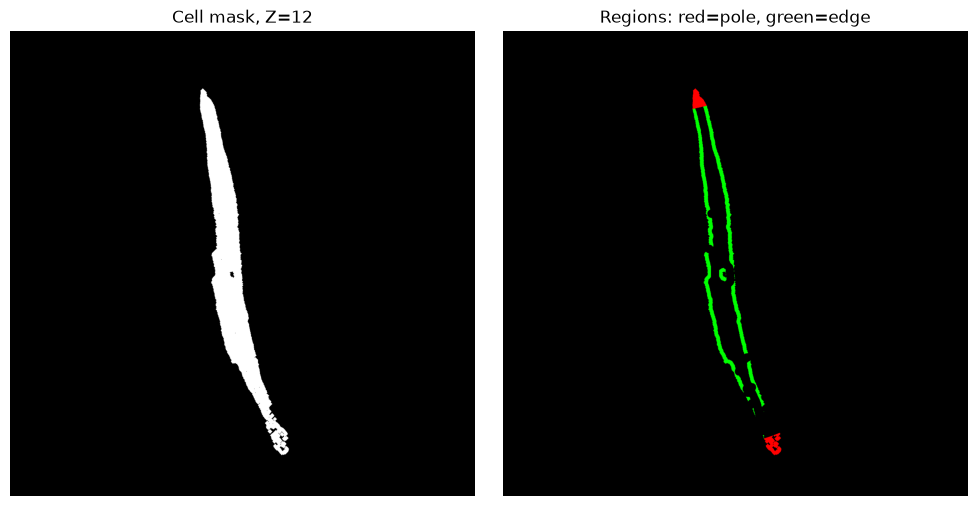

In [ ]:
# Quick 2D sanity check on a single Z slice (no napari session needed)
z_check = cell_mask.shape[0] // 2

overlay = np.zeros(cell_mask.shape[1:] + (3,), dtype=float)
overlay[edge_region[z_check]] = (0, 1, 0)   # green = edge/sides
overlay[pole_region[z_check]] = (1, 0, 0)   # red = pole

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cell_mask[z_check], cmap="gray")
axes[0].set_title(f"Cell mask, Z={z_check}")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Regions: red=pole, green=edge")
axes[1].axis("off")

fig.tight_layout()
plt.show()

## Analysis: per-cell channel intensity, end vs side, colocalization

Loops over every cell found by `find_channel_file_groups`, rebuilds the mask/pole/edge regions for each, then measures:

1. **Per (non-DAPI) channel, mean intensity in "End" (pole) vs "Side" (edge) regions.** DAPI is identified automatically from each TIFF's embedded channel metadata (SlideBook writes a private tag like `'Channel Name: c405 SoRa;445 nm;'` -- the channel whose label contains `405` is DAPI), not assumed to be a fixed channel index. Channels are labeled by their short excitation code (e.g. `488`, `561`).
2. **Colocalization between the two non-DAPI channels, compared across three regions**: the Whole cell mask, the Side (edge) region, and the End (pole) region. Pearson r, plus Manders M1/M2 -- thresholding each channel with Otsu *within that region* to define "positive" pixels, since raw intensity is essentially never exactly zero for real sensor data.

Outputs go into two folders next to `FolderOI`, both prefixed with the data folder's own name (e.g. `Colo_20260707_results`) so either can be copied/zipped and sent on its own, self-identifying without its parent folder:

- **`{folder_prefix}_results/`** -- the small, easy-to-send bundle: three tidy CSVs (`end_vs_side_intensity.csv`, `colocalization.csv` with a `region` column, `per_pixel_intensity_sample.csv`) so the data can be re-plotted however you like (`Sex`/`Date` columns parsed from the filename), plus the two summary graphs (`end_vs_side_intensity.png`, `colocalization_coefficients.png`).
- **`{folder_prefix}_RepImages/`** -- everything image-heavy: `scatter plots/` (one overview PNG per cell: composite thumbnail + Whole/Side/End scatter panels), `region_qc/` (one single-Z-slice composite+region-overlay PNG per cell), and `tiffs/<cell name>/` (real 3D `combined.tif`/`mask.tif`/`sides.tif`/`ends.tif` stacks, viewable directly in ImageJ).

This can take a while to run across all cells (rebuilds the full mask/pole/edge pipeline, plus writes several files, per cell) -- progress is printed per cell, and a cell that fails to segment is skipped (logged) rather than halting the whole batch. Set `show_cell_plots = True` in the config cell to also display each overview/QC plot inline while testing on a small `max_cells`.

In [ ]:
_CHANNEL_TAG_NAME = "65004"  # SlideBook's private ImageJ/TIFF tag, e.g. 'Channel Name: c405 SoRa;445 nm;'
_EXCITATION_CODE_RE = re.compile(r"\bc(\d+)\b")
_DATE_RE = re.compile(r"^(\d{4})\.(\d{2})\.(\d{2})")

region_order = ["Whole", "Side", "End"]  # shared region ordering, reused by process_cell and the plots below


def read_channel_label(filepath):
    """Read this TIFF's embedded channel metadata and return just the
    excitation code (e.g. '405', '488'), without the leading 'c' --
    parsed out of SlideBook's private tag, formatted like
    'Channel Name: c405 SoRa;445 nm;'. Falls back to the full tag text if
    the excitation-code pattern isn't found, or None if the tag is missing.
    """
    with tifffile.TiffFile(filepath) as tif:
        for tag in tif.pages[0].tags:
            if tag.name == _CHANNEL_TAG_NAME:
                match = _EXCITATION_CODE_RE.search(tag.value)
                return match.group(1) if match else tag.value
    return None


def channel_labels_for_group(file_group):
    """file_group: {channel_index: filepath} -> {channel_index: label}."""
    return {c: read_channel_label(f) for c, f in file_group.items()}


def find_dapi_channel(labels, dapi_marker="405"):
    """Return the channel index whose label contains `dapi_marker`
    (e.g. '405' for DAPI), or None if no channel matches.
    """
    for c, label_str in labels.items():
        if label_str and dapi_marker in label_str:
            return c
    return None


def short_cell_name(cell_id):
    """Shorten a cell_id by dropping the '_XY<pos>_Z..._T..._C...' suffix,
    e.g. '2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1_XY1783431107_Z00_T0'
    -> '2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1'.
    """
    return re.split(r"_XY\d+", cell_id)[0]


def parse_sex_and_date(cell_id):
    """Parse Sex ('Female'/'Male') and acquisition Date (as a 'YYYY-MM-DD'
    string, or None) from a cell_id/filename like
    '2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1_XY...'.
    """
    sex = "Female" if "female" in cell_id.lower() else "Male"
    m = _DATE_RE.match(cell_id)
    date_str = f"{m.group(1)}-{m.group(2)}-{m.group(3)}" if m else None
    return sex, date_str

In [ ]:
def measure_region_intensity(stack, region3d, channel_idx):
    """Mean intensity of stack[channel_idx] within the (Z, Y, X) bool
    `region3d`. NaN if the region is empty.
    """
    voxels = stack[channel_idx][region3d]
    return float(voxels.mean()) if voxels.size else np.nan


def pearson_and_manders(intensity_a, intensity_b):
    """Pearson r and Manders M1/M2 between two equal-length 1D intensity
    arrays drawn from the same pixels/voxels of two channels.

    Manders thresholds each channel with Otsu (computed on these same
    values, i.e. within whatever region they were extracted from) to
    define "positive" pixels -- unthresholded Manders isn't meaningful for
    real sensor data, which is essentially never exactly zero.
    """
    if intensity_a.size < 2:
        return np.nan, np.nan, np.nan

    r = float(np.corrcoef(intensity_a, intensity_b)[0, 1])

    thresh_a = threshold_otsu(intensity_a) if intensity_a.max() > intensity_a.min() else intensity_a.min()
    thresh_b = threshold_otsu(intensity_b) if intensity_b.max() > intensity_b.min() else intensity_b.min()
    positive_a = intensity_a > thresh_a
    positive_b = intensity_b > thresh_b

    sum_a, sum_b = intensity_a.sum(), intensity_b.sum()
    m1 = float(intensity_a[positive_b].sum() / sum_a) if sum_a > 0 else np.nan
    m2 = float(intensity_b[positive_a].sum() / sum_b) if sum_b > 0 else np.nan
    return r, m1, m2

In [ ]:
_DAPI_COLOR = (0.5, 0.5, 0.5)  # grey
_OTHER_CHANNEL_COLORS = [
    (0.0, 1.0, 1.0),  # Cyan
    (1.0, 0.0, 1.0),  # Magenta
    (1.0, 1.0, 0.0),  # Yellow
    (1.0, 0.0, 0.0),  # Red (fallback if there are more than 3 non-DAPI channels)
    (0.0, 1.0, 0.0),  # Green
    (0.0, 0.0, 1.0),  # Blue
]


def _percentile_normalize(image, low=1.0, high=99.8):
    """Contrast-stretch `image` between its low/high percentiles instead of
    its true min/max. A plain divide-by-max normalization gets wrecked by
    a single hot/saturated pixel, which then dominates the max and washes
    out everything else -- this is the same "auto contrast" idea as the
    original ImageJ macro's own `run("Enhance Contrast", "saturated=0.35")`
    step.
    """
    lo, hi = np.percentile(image, [low, high])
    if hi <= lo:
        return np.zeros_like(image, dtype=np.float32)
    stretched = (image.astype(np.float32) - lo) / (hi - lo)
    return np.clip(stretched, 0, 1)


def build_max_projection_composite(stack, dapi_channel, other_channels, dapi_brightness=0.5):
    """Max-project each channel across Z, auto-contrast it
    (_percentile_normalize), and additively blend into an RGB (Y, X, 3)
    composite: DAPI (if present) -> grey, other channels -> cyan, magenta,
    yellow, ... in order (cycling through _OTHER_CHANNEL_COLORS if there
    are more than 3 non-DAPI channels).

    DAPI is dimmed by `dapi_brightness` (default 0.5, i.e. its brightest
    pixel only reaches half of full scale -- effectively normalized as if
    the display max were 2x its actual max) so it doesn't dominate the
    composite over the channels of actual interest.

    Used for the 2D thumbnail in plot_cell_overview. See build_3d_composite
    for the real per-Z 3D version used for the TIFF export / region QC plot.
    """
    composite = np.zeros(stack.shape[-2:] + (3,), dtype=np.float32)

    if dapi_channel is not None:
        stretched = _percentile_normalize(stack[dapi_channel].max(axis=0)) * dapi_brightness
        composite += stretched[..., None] * np.array(_DAPI_COLOR, dtype=np.float32)

    for i, c in enumerate(other_channels):
        color = _OTHER_CHANNEL_COLORS[i % len(_OTHER_CHANNEL_COLORS)]
        stretched = _percentile_normalize(stack[c].max(axis=0))
        composite += stretched[..., None] * np.array(color, dtype=np.float32)

    return np.clip(composite, 0, 1)


def build_3d_composite(stack, dapi_channel, other_channels, dapi_brightness=0.5):
    """Same channel/color scheme as build_max_projection_composite, but
    auto-contrasted over the *entire 3D volume* and combined per Z slice
    instead of only on a max projection -- a genuine 3D RGB stack, for
    saving as a real Z-stack TIFF (see save_cell_tiffs) or displaying one
    slice at a time (see plot_cell_regions_qc), rather than a single
    flattened thumbnail.
    """
    composite = np.zeros(stack.shape[1:] + (3,), dtype=np.float32)  # (Z, Y, X, 3)

    if dapi_channel is not None:
        stretched = _percentile_normalize(stack[dapi_channel]) * dapi_brightness
        composite += stretched[..., None] * np.array(_DAPI_COLOR, dtype=np.float32)

    for i, c in enumerate(other_channels):
        color = _OTHER_CHANNEL_COLORS[i % len(_OTHER_CHANNEL_COLORS)]
        stretched = _percentile_normalize(stack[c])
        composite += stretched[..., None] * np.array(color, dtype=np.float32)

    return np.clip(composite, 0, 1)


def downsize_composite(composite, size=200):
    """Resize an (Y, X, 3) composite down to (size, size, 3) -- keeps each
    saved thumbnail reasonably light.
    """
    return resize(composite, (size, size, 3), anti_aliasing=True, preserve_range=True)


def save_cell_tiffs(short_name, composite_3d, cell_mask, edge_region, pole_region, output_dir):
    """Save this cell's 3D stacks as TIFFs viewable in ImageJ, in a
    subfolder named after the cell: the auto-contrasted RGB channel
    composite ("combined.tif"), the cell mask ("mask.tif"), the Side/edge
    region ("sides.tif"), and the End/pole region ("ends.tif") -- each a
    real (Z, Y, X[, 3]) stack, not a flattened projection.
    """
    safe_name = re.sub(r'[\\/*?:"<>|]', "_", short_name)
    cell_dir = os.path.join(output_dir, safe_name)
    os.makedirs(cell_dir, exist_ok=True)

    composite_uint8 = (composite_3d * 255).astype(np.uint8)
    tifffile.imwrite(os.path.join(cell_dir, "combined.tif"), composite_uint8, photometric="rgb")
    tifffile.imwrite(os.path.join(cell_dir, "mask.tif"), cell_mask.astype(np.uint8) * 255)
    tifffile.imwrite(os.path.join(cell_dir, "sides.tif"), edge_region.astype(np.uint8) * 255)
    tifffile.imwrite(os.path.join(cell_dir, "ends.tif"), pole_region.astype(np.uint8) * 255)


_SEX_COLORS = {"Female": "#d6336c", "Male": "#1971c2"}


_NICE_SCALE_LENGTHS_UM = [1, 2, 5, 10, 20, 25, 50, 100, 200, 250, 500, 1000, 2000, 5000]


def read_pixel_size_um(filepath):
    """Read the XY pixel size (microns/pixel) from a TIFF's resolution
    tags, assuming the ImageJ convention: XResolution/YResolution are
    pixels-per-unit, and imagej_metadata['unit'] gives the unit (expected
    'micron' for this project's data, e.g. XResolution=(1552417, 262144)
    with unit='micron' -> ~0.169 um/pixel). Returns None if it can't be
    determined, so callers can just skip drawing a scale bar.
    """
    with tifffile.TiffFile(filepath) as tif:
        ij_meta = tif.imagej_metadata or {}
        if ij_meta.get("unit") not in ("micron", "um", "\u00b5m"):
            return None
        xres_tag = tif.pages[0].tags.get("XResolution")
        if xres_tag is None or xres_tag.value[0] == 0:
            return None
        num, den = xres_tag.value
        return den / num


def _choose_scale_bar_length_um(fov_width_um, target_fraction=0.22):
    """Pick the largest "nice" length (50/100/200 um, etc., from
    _NICE_SCALE_LENGTHS_UM) that doesn't exceed target_fraction of the
    field-of-view width -- the biggest bar that still comfortably fits.
    """
    target = fov_width_um * target_fraction
    candidates = [length for length in _NICE_SCALE_LENGTHS_UM if length <= target]
    return candidates[-1] if candidates else _NICE_SCALE_LENGTHS_UM[0]


def add_scale_bar(ax, image_width_px, image_height_px, um_per_px, color="white"):
    """Draw an auto-sized scale bar (50/100/200 um, etc. -- whichever best
    fits) in the bottom-right quarter of `ax` (an imshow axis). No-op if
    `um_per_px` is None (pixel size couldn't be determined).
    """
    if um_per_px is None:
        return
    fov_width_um = image_width_px * um_per_px
    length_um = _choose_scale_bar_length_um(fov_width_um)
    length_px = length_um / um_per_px

    margin_x = image_width_px * 0.05
    margin_y = image_height_px * 0.08
    x_end = image_width_px - margin_x
    x_start = x_end - length_px
    y = image_height_px - margin_y

    ax.plot([x_start, x_end], [y, y], color=color, linewidth=3, solid_capstyle="butt")
    ax.text(
        (x_start + x_end) / 2, y - image_height_px * 0.02, f"{length_um:g} \u00b5m",
        color=color, ha="center", va="bottom", fontsize=9, fontweight="bold",
    )


def plot_cell_regions_qc(short_name, sex, date_str, composite_3d, cell_mask, edge_region, pole_region,
                          output_dir, um_per_px=None, z=None, show=False):
    """2D sanity-check plot at a single Z slice: the auto-contrasted
    channel composite next to an overlay of the pole (red) and edge
    (green) regions -- a quick way to spot-check the 3D regions without
    opening ImageJ. Defaults to the middle Z slice. Draws an auto-sized
    scale bar (see add_scale_bar) on both panels if `um_per_px` is given.
    """
    if z is None:
        z = cell_mask.shape[0] // 2

    overlay = np.zeros(cell_mask.shape[1:] + (3,), dtype=float)
    overlay[edge_region[z]] = (0, 1, 0)
    overlay[pole_region[z]] = (1, 0, 0)

    sex_color = _SEX_COLORS.get(sex, "black")
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    img_h, img_w = composite_3d.shape[1], composite_3d.shape[2]

    axes[0].imshow(composite_3d[z])
    axes[0].set_title(f"Composite, Z={z}")
    axes[0].axis("off")
    add_scale_bar(axes[0], img_w, img_h, um_per_px)

    axes[1].imshow(overlay)
    axes[1].set_title("Regions: red=pole, green=edge")
    axes[1].axis("off")
    add_scale_bar(axes[1], img_w, img_h, um_per_px)

    fig.suptitle(f"{short_name}  ({sex}, {date_str})", color=sex_color, fontsize=12, fontweight="bold")
    fig.tight_layout()

    safe_name = re.sub(r'[\\/*?:"<>|]', "_", short_name)
    fig.savefig(os.path.join(output_dir, f"{safe_name}_regions_qc.png"), dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_cell_overview(data, output_dir, show=False, xlim=None, ylim=None):
    """Save one PNG for a single cell: its composite thumbnail alongside a
    channel-1-vs-channel-2 scatter panel for each region in region_order
    (Whole/Side/End). The Whole/Side/End panels share the same x/y limits,
    taken from this cell's Whole-region data (Side/End are subsets of it)
    -- so the panels are directly comparable, instead of each auto-scaling
    to fit its own (often much smaller) data range.

    `data` is one cell_plot_data dict, as returned by process_cell.

    `xlim`/`ylim` override the auto-derived (from this data's own Whole
    region) axis limits -- e.g. so a set of per-Z-slice plots for the same
    cell can all share one cell-wide scale and stay visually comparable to
    each other, instead of each slice auto-scaling to its own (much
    smaller) per-slice pixel range.
    """
    sex_color = _SEX_COLORS.get(data["sex"], "black")

    n_cols = 1 + len(region_order)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.5))

    axes[0].imshow(data["composite"])
    axes[0].axis("off")
    axes[0].set_title(f"{data['short_name']}\n({data['sex']}, {data['date_str']})", color=sex_color, fontsize=10)

    region_scatter_data = data["region_scatter_data"]
    if xlim is None or ylim is None:
        ref_a, ref_b = region_scatter_data.get("Whole", (np.array([]), np.array([])))
        if ref_a.size == 0:
            all_a = [v[0] for v in region_scatter_data.values() if v[0].size]
            all_b = [v[1] for v in region_scatter_data.values() if v[1].size]
            ref_a = np.concatenate(all_a) if all_a else ref_a
            ref_b = np.concatenate(all_b) if all_b else ref_b
        if xlim is None:
            xlim = (float(ref_a.min()), float(ref_a.max())) if ref_a.size else None
        if ylim is None:
            ylim = (float(ref_b.min()), float(ref_b.max())) if ref_b.size else None

    region_fit_data = data.get("region_fit_data", {})
    for ax, region_name in zip(axes[1:], region_order):
        a, b = region_scatter_data.get(region_name, (np.array([]), np.array([])))
        ax.scatter(a, b, color="#333333", alpha=0.5, s=20, edgecolor="white", linewidth=0.3)
        ax.set_title(region_name)
        ax.set_xlabel(f"{data['channel_1_label']} nm")
        ax.set_ylabel(f"{data['channel_2_label']} nm")
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)

        fit = region_fit_data.get(region_name)
        if fit is not None:
            r, slope, intercept = fit
            line_x = np.asarray(ax.get_xlim(), dtype=float)
            ax.plot(line_x, slope * line_x + intercept, color="crimson", linewidth=1.5)
            if not np.isnan(r):
                ax.text(
                    0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                    ha="left", va="top", fontsize=9, fontweight="bold", color="crimson",
                )

    sns.despine(fig)
    fig.tight_layout()

    safe_name = re.sub(r'[\\/*?:"<>|]', "_", data["short_name"])
    fig.savefig(os.path.join(output_dir, f"{safe_name}.png"), dpi=150)
    if show:
        plt.show()
    else:
        plt.close(fig)

In [ ]:
max_scatter_points_per_cell = 5000  # subsample cap for the scatter grid panels only -- stats below always use the full pixel set
composite_thumbnail_size = 200      # per-cell composite thumbnail resolution in plot_cell_overview


def process_cell(cell_id, file_group, dapi_marker="405", rng=None, tiff_dir=None, qc_dir=None):
    """Run the full mask/pole/edge pipeline for one cell (file_group), then
    measure per-(non-DAPI)-channel mean intensity in the End (pole) and
    Side (edge) regions, plus Pearson/Manders colocalization between the
    two non-DAPI channels within each of three regions: the Whole cell
    mask, the Side (edge) region, and the End (pole) region.

    If `tiff_dir` is given, also saves this cell's 3D TIFFs (combined
    composite, mask, sides, ends -- see save_cell_tiffs) into a subfolder
    there. If `qc_dir` is given, also saves (and, per the global
    show_cell_plots, displays) a single-Z-slice composite+region overlay
    QC plot there (see plot_cell_regions_qc).

    Returns (intensity_rows, coloc_rows, scatter_rows, cell_plot_data):
    - intensity_rows: list of dicts, one per non-DAPI channel x (End/Side) region.
    - coloc_rows: list of dicts, one per (Whole/Side/End) region, each this
      cell's colocalization stats using every pixel in that region. Empty
      if there aren't at least 2 non-DAPI channels or segmentation failed.
    - scatter_rows: list of dicts (cell_id, region, intensity_1,
      intensity_2), a random subsample (up to max_scatter_points_per_cell
      per region) of the same pixels, for CSV export / re-plotting.
    - cell_plot_data: dict with this cell's composite thumbnail + scatter
      data (plus a per-region regression line + Pearson r, in
      "region_fit_data", fit on the full pixel set), for plot_cell_overview
      -- None if there weren't at least 2 non-DAPI channels or segmentation
      failed.
    """
    if rng is None:
        rng = np.random.default_rng()

    short_name = short_cell_name(cell_id)
    sex, date_str = parse_sex_and_date(cell_id)

    labels = channel_labels_for_group(file_group)
    dapi_channel = find_dapi_channel(labels, dapi_marker=dapi_marker)
    other_channels = [c for c in sorted(file_group) if c != dapi_channel]
    um_per_px = read_pixel_size_um(next(iter(file_group.values())))

    stack = load_channel_stack(file_group)

    try:
        cell_mask = build_cell_mask(
            stack, seg_channels=seg_channels, min_size=min_size,
            open_iterations=open_iterations, min_slice_size=min_slice_size,
        )
        pole1, pole2, skeleton2d = find_poles(cell_mask)
    except ValueError as e:
        print(f"  [{cell_id}] segmentation failed, skipping: {e}")
        return [], [], [], None

    upper_region, _, _ = per_slice_pole_cap_region(
        cell_mask, pole1, skeleton2d, arc_length=pole_arc_length, min_component_size=min_pole_component_size,
    )
    lower_region, _, _ = per_slice_pole_cap_region(
        cell_mask, pole2, skeleton2d, arc_length=pole_arc_length, min_component_size=min_pole_component_size,
    )
    pole_region = smooth_region_3d(upper_region | lower_region, radius=pole_smooth_radius, clip_to=cell_mask)
    edge_region = build_edge_region(
        cell_mask, [pole_region],
        erode_radius=edge_erode_radius, skeleton_dilate_radius=skeleton_dilate_radius,
        mask_erode_radius=cell_mask_erode_radius,
    )

    intensity_rows = []
    for c in other_channels:
        for region_name, region in (("End", pole_region), ("Side", edge_region)):
            intensity_rows.append({
                "cell_id": cell_id,
                "channel": labels.get(c) or f"C{c}",
                "region": region_name,
                "mean_intensity": measure_region_intensity(stack, region, c),
            })

    coloc_rows = []
    scatter_rows = []
    cell_plot_data = None
    if len(other_channels) >= 2:
        c1, c2 = other_channels[0], other_channels[1]
        channel_1_label = labels.get(c1) or f"C{c1}"
        channel_2_label = labels.get(c2) or f"C{c2}"
        # every non-DAPI channel's label, for naming a column per channel in
        # the scatter CSV below (not just the c1/c2 pair used for coloc stats)
        channel_labels_all = {c: (labels.get(c) or f"C{c}") for c in other_channels}

        region_scatter_data = {}
        region_fit_data = {}
        for region_name, region in (("Whole", cell_mask), ("Side", edge_region), ("End", pole_region)):
            intensity_a = stack[c1][region].astype(np.float64)
            intensity_b = stack[c2][region].astype(np.float64)
            r, m1, m2 = pearson_and_manders(intensity_a, intensity_b)
            coloc_rows.append({
                "cell_id": cell_id,
                "region": region_name,
                "channel_1": channel_1_label,
                "channel_2": channel_2_label,
                "pearson_r": r,
                "manders_m1": m1,
                "manders_m2": m2,
                "n_pixels": int(intensity_a.size),
            })

            # Least-squares line through the *full* pixel set (same data
            # pearson_and_manders just used), not the subsample below -- so
            # the plotted line/r always match what's in colocalization.csv,
            # regardless of the scatter's subsample cap. Skipped if there's
            # no x-variation to fit against (a flat vertical line isn't a
            # function of x).
            if intensity_a.size >= 2 and intensity_a.std() > 0:
                slope, intercept = np.polyfit(intensity_a, intensity_b, 1)
                region_fit_data[region_name] = (r, float(slope), float(intercept))

            n = intensity_a.size
            if n > 0:
                idx = rng.choice(n, size=min(n, max_scatter_points_per_cell), replace=False)
                sampled_a, sampled_b = intensity_a[idx], intensity_b[idx]
                region_scatter_data[region_name] = (sampled_a, sampled_b)

                # Sample every non-DAPI channel at these same pixel indices
                # (not just c1/c2), each in its own label-named column (e.g.
                # '488', '555', '647') -- avoids the ambiguity of a fixed
                # intensity_1/intensity_2 pair, since which physical channel
                # ends up "first" (lowest surviving channel index) can differ
                # between acquisitions, and supports however many non-DAPI
                # channels are actually present (2 or more).
                channel_samples = {
                    channel_labels_all[c]: stack[c][region][idx].astype(np.float64)
                    for c in other_channels
                }
                for i in range(len(idx)):
                    row = {"cell_id": cell_id, "region": region_name}
                    for label_name, values in channel_samples.items():
                        row[label_name] = float(values[i])
                    scatter_rows.append(row)

        composite_dapi_channel = dapi_channel if show_dapi_in_composite else None
        composite = build_max_projection_composite(stack, composite_dapi_channel, other_channels)

        cell_plot_data = {
            "short_name": short_name,
            "sex": sex,
            "date_str": date_str,
            "composite": downsize_composite(composite, size=composite_thumbnail_size),
            "region_scatter_data": region_scatter_data,
            "region_fit_data": region_fit_data,
            "channel_1_label": channel_1_label,
            "channel_2_label": channel_2_label,
        }

        # Additional outputs, on top of the above: a real 3D (per-Z) composite
        # for the TIFF export and the region QC plot, computed separately
        # from the flat thumbnail above.
        if tiff_dir is not None or qc_dir is not None:
            composite_3d = build_3d_composite(stack, composite_dapi_channel, other_channels)

            if tiff_dir is not None:
                save_cell_tiffs(short_name, composite_3d, cell_mask, edge_region, pole_region, tiff_dir)

            if qc_dir is not None:
                plot_cell_regions_qc(
                    short_name, sex, date_str, composite_3d, cell_mask, edge_region, pole_region,
                    qc_dir, um_per_px=um_per_px, show=show_cell_plots,
                )

    return intensity_rows, coloc_rows, scatter_rows, cell_plot_data

[1/59] 2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 10_XY1783431988_Z00_T0


C:\Users\jszczerkowski\AppData\Local\Temp\ipykernel_25752\3432274927.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask3d[z] = remove_small_objects(opened, min_size=min_slice_size)


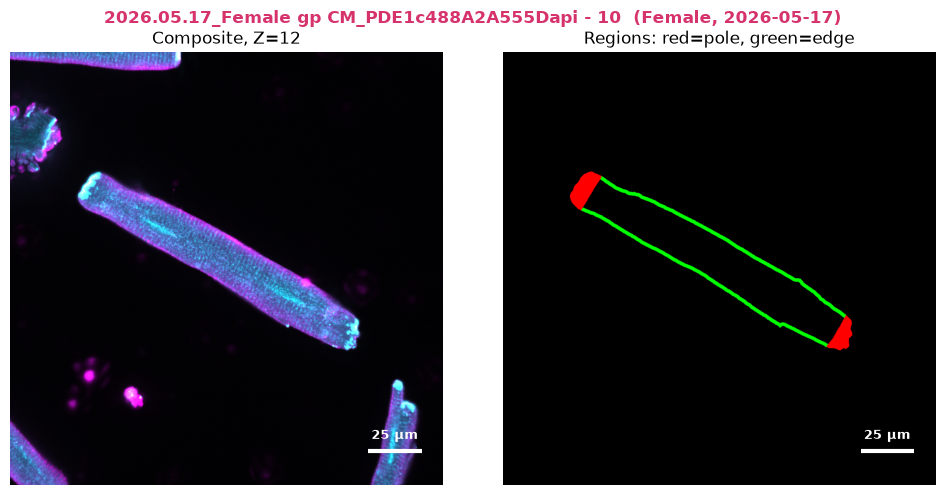

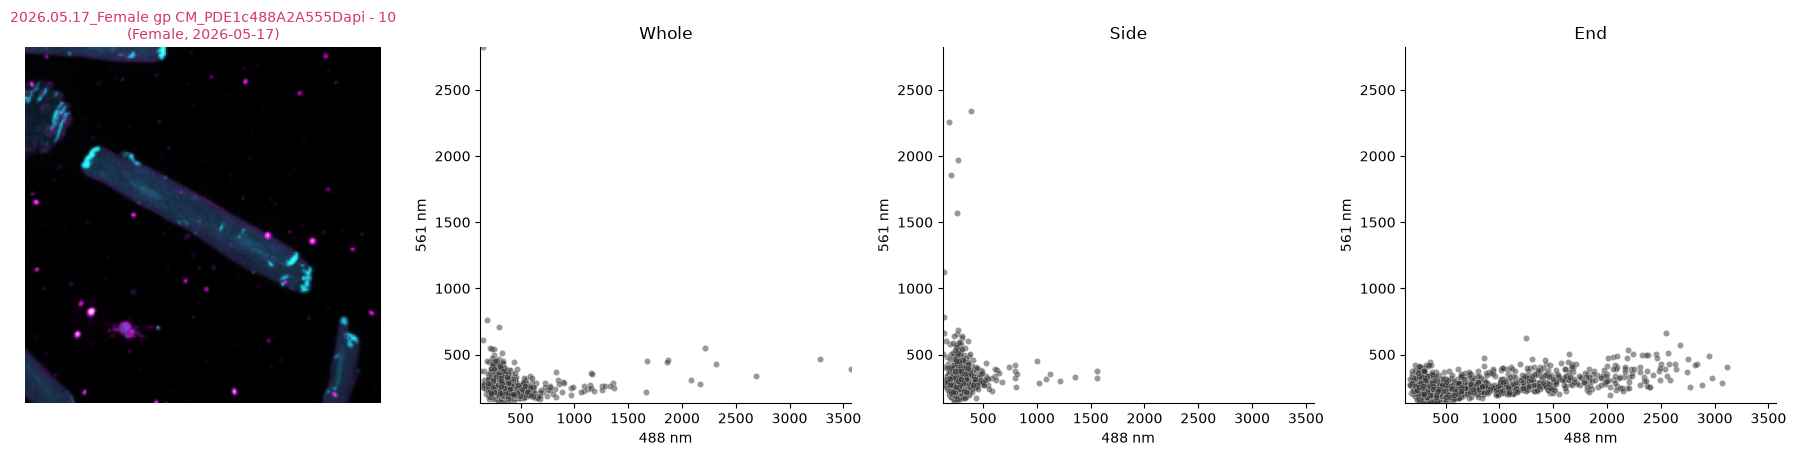

[2/59] 2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 11_XY1783432062_Z00_T0


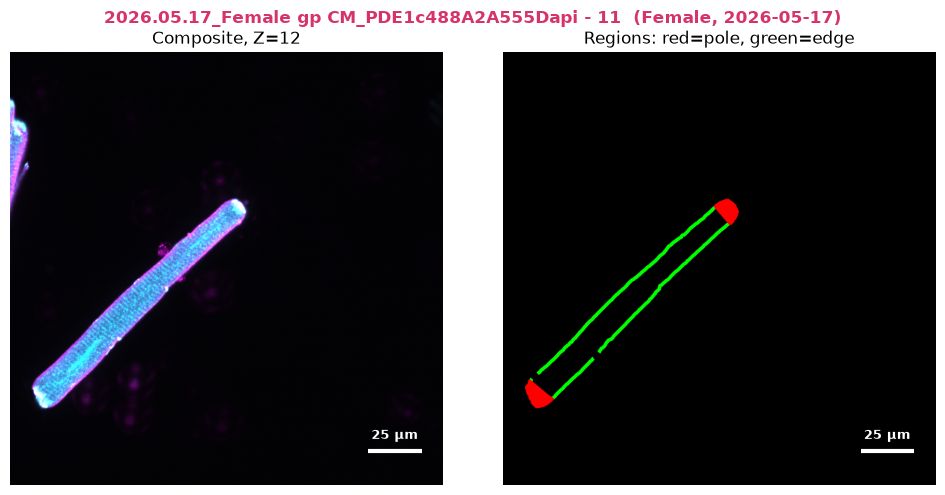

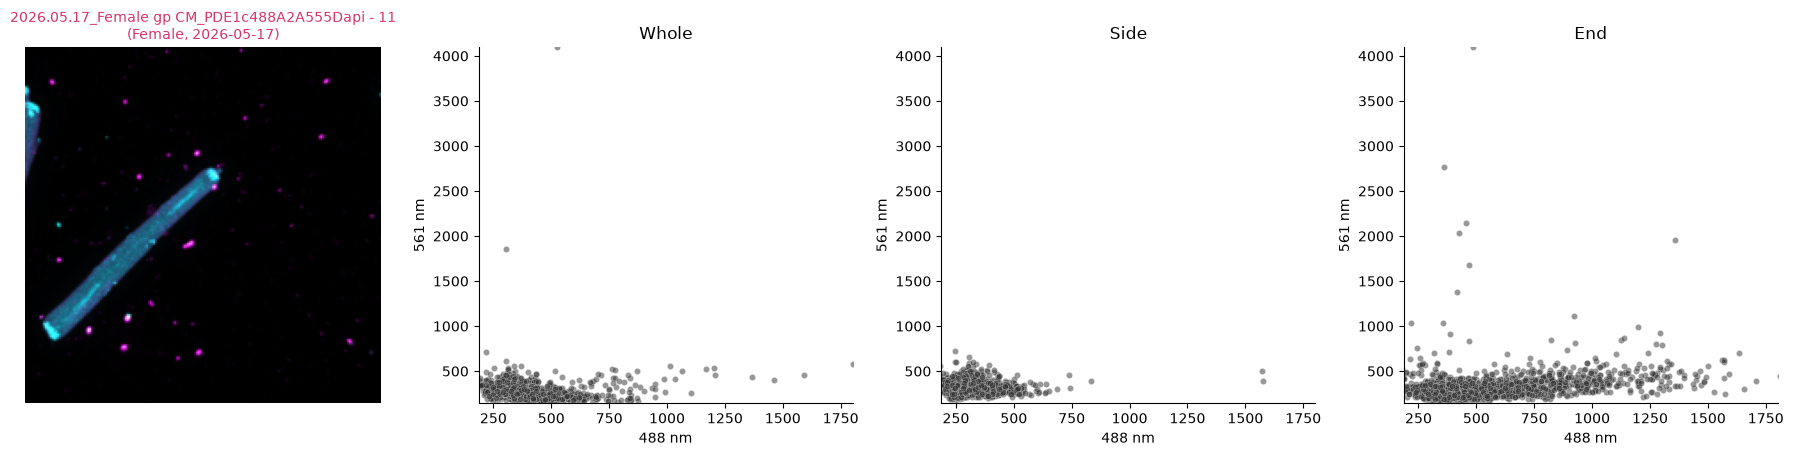

[3/59] 2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 12_XY1783432139_Z00_T0


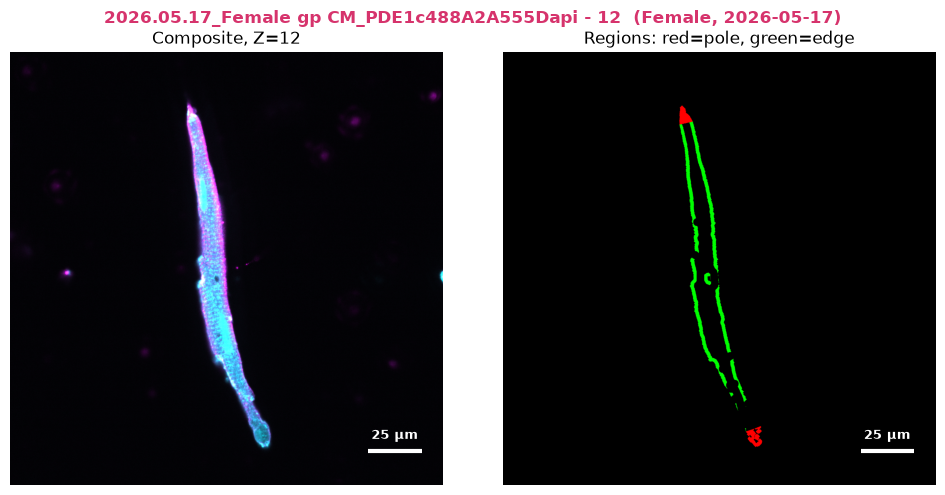

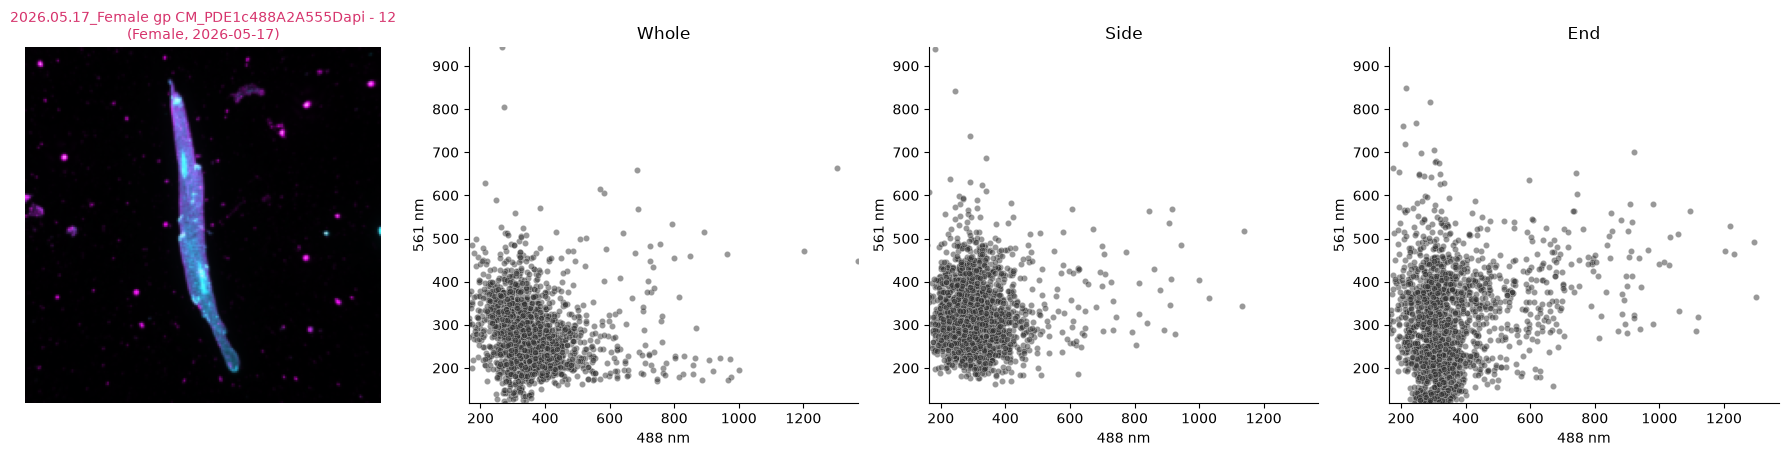

[4/59] 2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 13_XY1783432212_Z00_T0


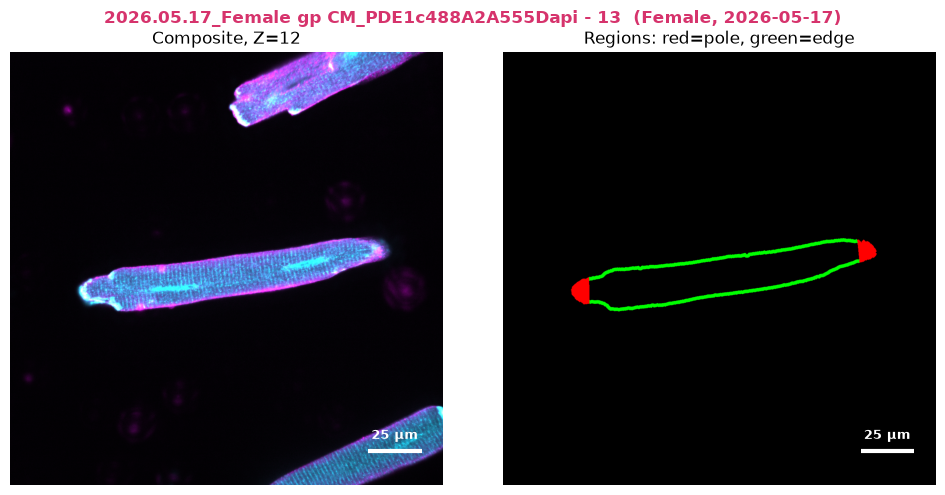

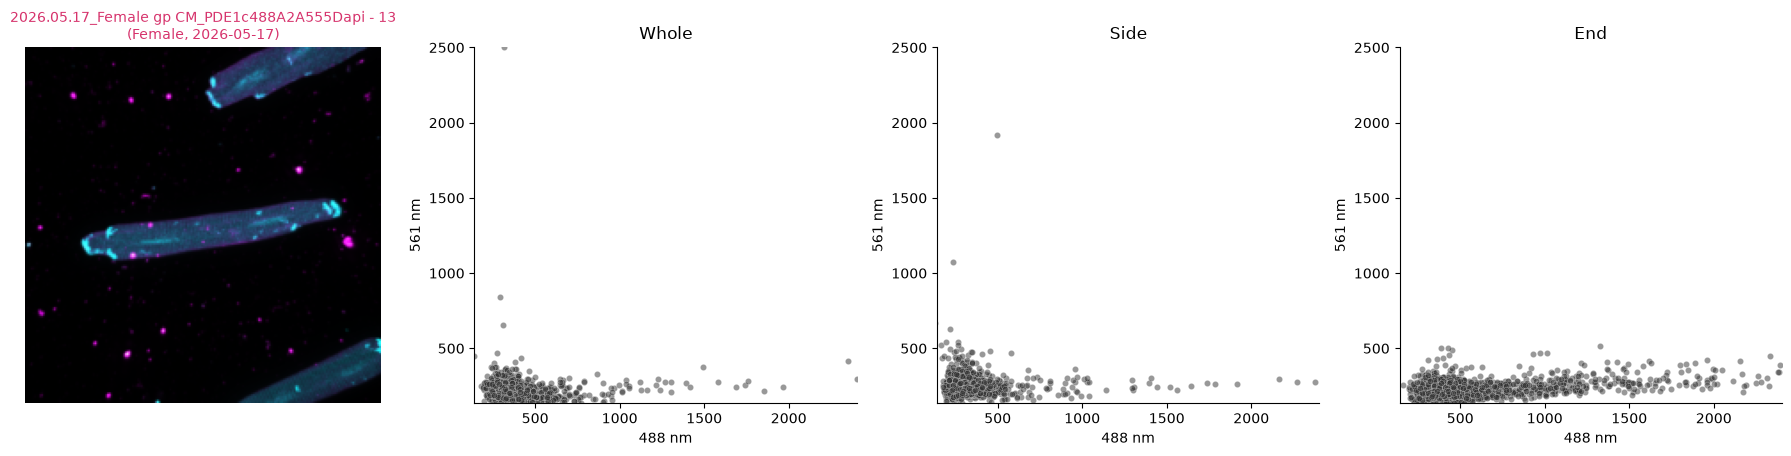

[5/59] 2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 14_XY1783432288_Z00_T0


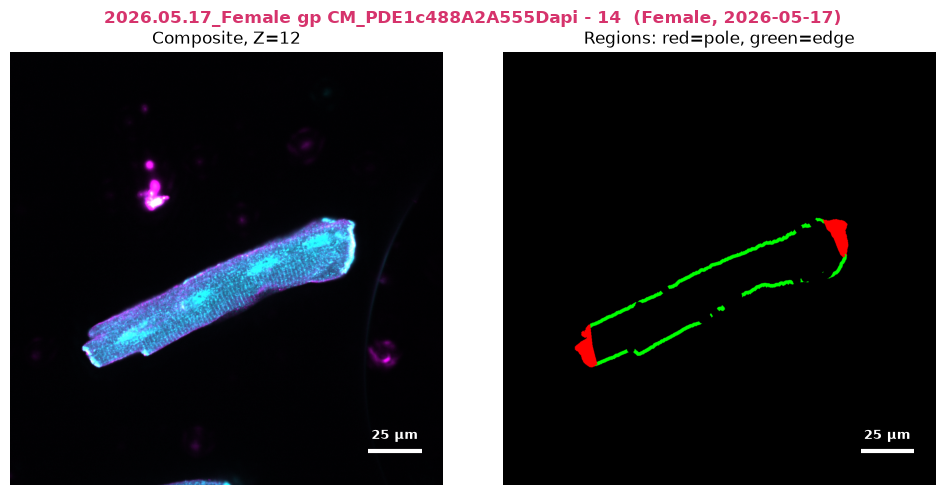

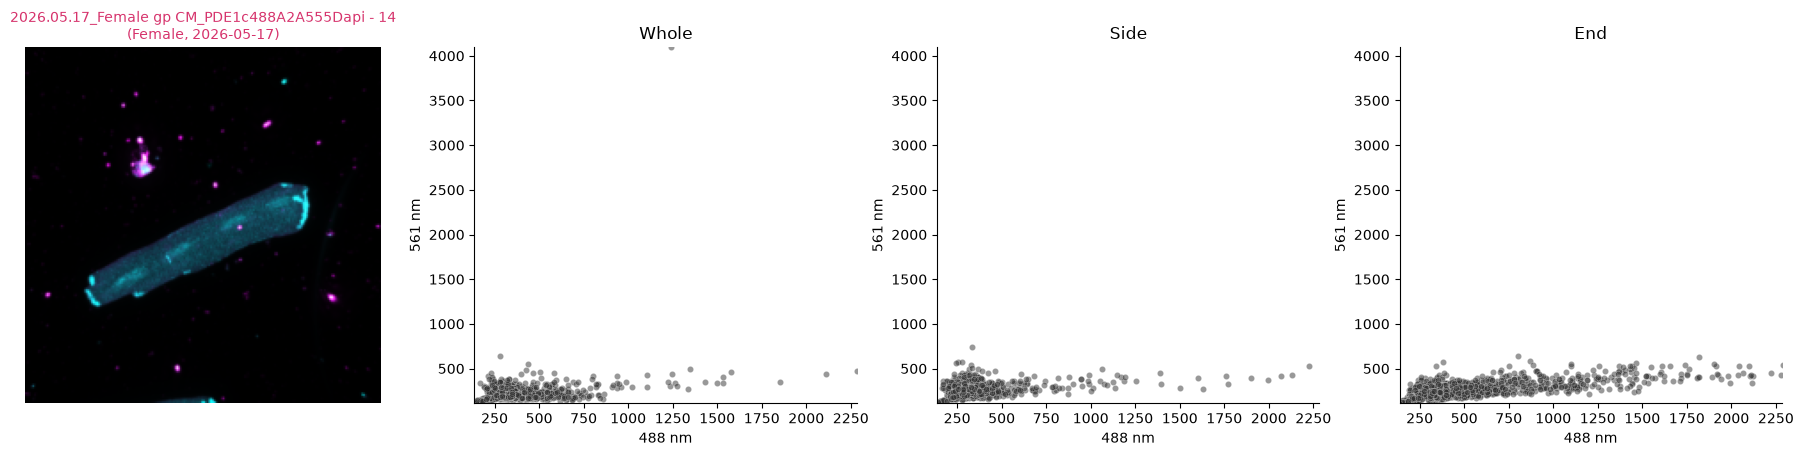


Processed 5 cells, 0 failed: []
Wrote C:\Users\jszczerkowski\Documents\Xana\Colocalisation\Colo_20260707\Colo_20260707_results\end_vs_side_intensity.csv
Wrote C:\Users\jszczerkowski\Documents\Xana\Colocalisation\Colo_20260707\Colo_20260707_results\colocalization.csv


,cell_id,channel,region,mean_intensity,Sex,Date
0,2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1...,488,End,611.555368,Female,2026-05-17
1,2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1...,488,Side,279.628454,Female,2026-05-17
2,2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1...,561,End,247.753870,Female,2026-05-17
3,2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1...,561,Side,302.322048,Female,2026-05-17
4,2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1...,488,End,540.062671,Female,2026-05-17


In [ ]:
max_cells = None # 5  # set to None to process every group; useful for a quick sanity check first

scatter_plots_dir = os.path.join(rep_images_dir, "scatter plots")
os.makedirs(scatter_plots_dir, exist_ok=True)

tiff_dir = os.path.join(rep_images_dir, "tiffs")
os.makedirs(tiff_dir, exist_ok=True)

qc_dir = os.path.join(rep_images_dir, "region_qc")
os.makedirs(qc_dir, exist_ok=True)

rng = np.random.default_rng(0)

intensity_records = []
coloc_records = []
scatter_records = []
cell_plot_records = []
failed_cells = []

for i, (base, file_group) in enumerate(groups.items()):
    if max_cells is not None and i >= max_cells:
        break
    cell_id = os.path.basename(base)
    print(f"[{i + 1}/{len(groups)}] {cell_id}")
    intensity_rows, coloc_rows, scatter_rows, cell_plot_data = process_cell(
        cell_id, file_group, rng=rng, tiff_dir=tiff_dir, qc_dir=qc_dir,
    )
    if not coloc_rows and not intensity_rows:
        failed_cells.append(cell_id)
    intensity_records.extend(intensity_rows)
    coloc_records.extend(coloc_rows)
    scatter_records.extend(scatter_rows)
    if cell_plot_data is not None:
        cell_plot_records.append(cell_plot_data)
        plot_cell_overview(cell_plot_data, scatter_plots_dir, show=show_cell_plots)

intensity_df = pd.DataFrame(intensity_records)
coloc_df = pd.DataFrame(coloc_records)
scatter_df = pd.DataFrame(scatter_records)

# Sex and acquisition Date from the cell/file name, e.g.
# "2026.05.17_Female gp CM_PDE1c488A2A555Dapi - 1_XY..." -> Date=2026-05-17, Sex=Female
for df in (intensity_df, coloc_df):
    if not df.empty:
        df["Sex"] = np.where(df["cell_id"].str.contains("female", case=False, na=False), "Female", "Male")
        df["Date"] = pd.to_datetime(df["cell_id"].str.extract(r"^(\d{4}\.\d{2}\.\d{2})")[0], format="%Y.%m.%d").dt.date

print(f"\nProcessed {len(intensity_df['cell_id'].unique()) if not intensity_df.empty else 0} cells, {len(failed_cells)} failed: {failed_cells}")

intensity_csv_path = os.path.join(results_dir, "end_vs_side_intensity.csv")
coloc_csv_path = os.path.join(results_dir, "colocalization.csv")
intensity_df.to_csv(intensity_csv_path, index=False)
coloc_df.to_csv(coloc_csv_path, index=False)
print(f"Wrote {intensity_csv_path}")
print(f"Wrote {coloc_csv_path}")

intensity_df.head()

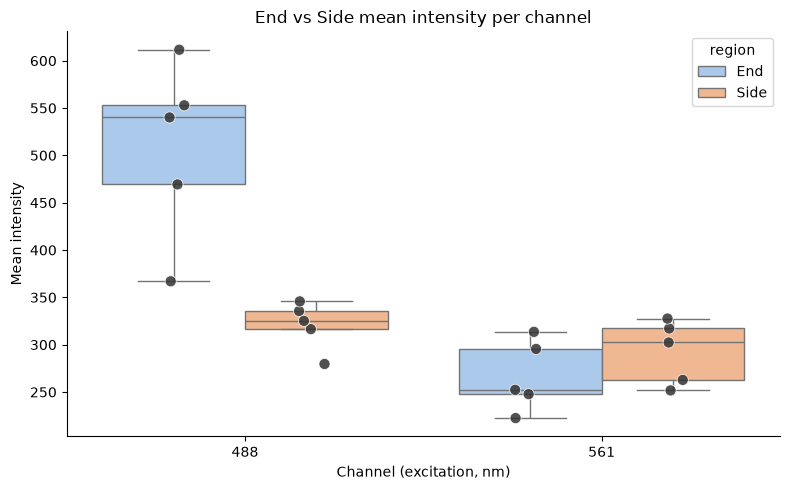

In [ ]:
# End vs Side mean intensity, per (non-DAPI) channel
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=intensity_df, x="channel", y="mean_intensity", hue="region", ax=ax,
    showfliers=False, palette="pastel",
)
sns.stripplot(
    data=intensity_df, x="channel", y="mean_intensity", hue="region",
    dodge=True, ax=ax, legend=False,
    # explicit 2-color palette (not `color=`) avoids seaborn's deprecated
    # color+hue gradient-inference, which otherwise gives two slightly
    # different grays instead of one true flat contrasting color
    palette=["#333333", "#333333"], size=8, alpha=0.85, edgecolor="white", linewidth=0.6,
)
ax.set_ylabel("Mean intensity")
ax.set_xlabel("Channel (excitation, nm)")
ax.set_title("End vs Side mean intensity per channel")
sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(results_dir, "end_vs_side_intensity.png"), dpi=200)
plt.show()

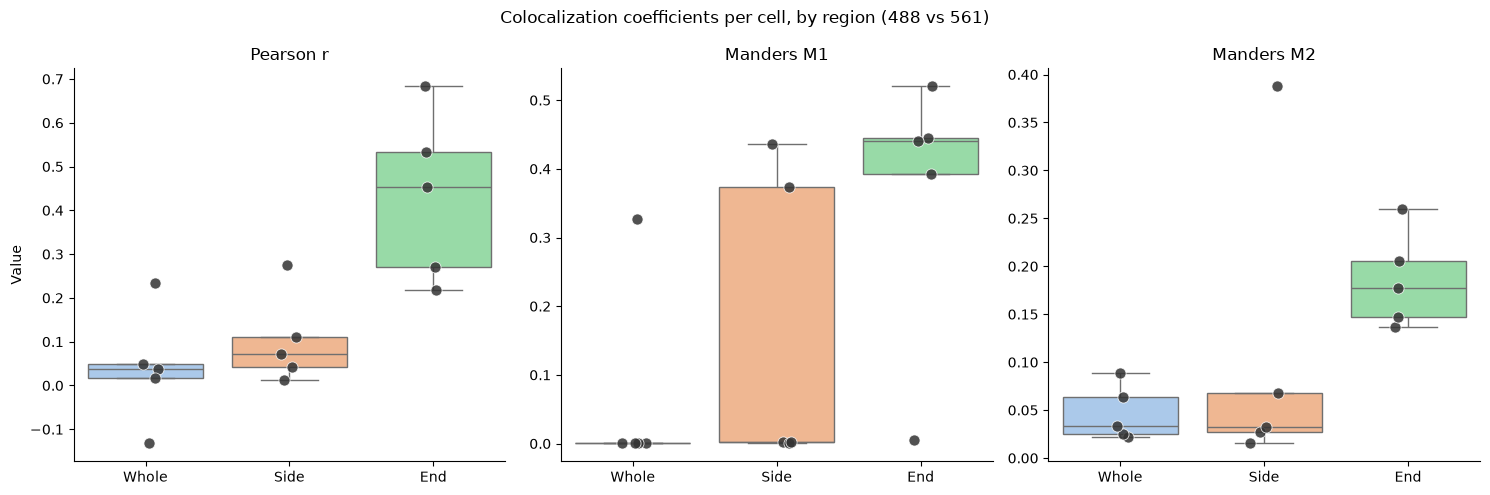

In [ ]:
# Per-cell colocalization coefficients, compared across Whole mask / Side / End regions
coeff_specs = [("pearson_r", "Pearson r"), ("manders_m1", "Manders M1"), ("manders_m2", "Manders M2")]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, (coeff_col, coeff_title) in zip(axes, coeff_specs):
    sns.boxplot(
        data=coloc_df, x="region", y=coeff_col, hue="region", order=region_order, ax=ax,
        showfliers=False, palette="pastel", legend=False,
    )
    sns.stripplot(
        data=coloc_df, x="region", y=coeff_col, order=region_order, ax=ax,
        color="#333333", size=8, alpha=0.85, edgecolor="white", linewidth=0.6,
    )
    ax.set_title(coeff_title)
    ax.set_xlabel("")
    ax.set_ylabel("Value" if ax is axes[0] else "")

title_channels = ""
if not coloc_df.empty:
    title_channels = f" ({coloc_df['channel_1'].iloc[0]} vs {coloc_df['channel_2'].iloc[0]})"
fig.suptitle(f"Colocalization coefficients per cell, by region{title_channels}")
sns.despine(fig)
fig.tight_layout()
fig.savefig(os.path.join(results_dir, "colocalization_coefficients.png"), dpi=200)
plt.show()

In [ ]:
# Export the underlying (subsampled) per-pixel scatter data, so it can be
# re-plotted/pooled however you like
scatter_csv_path = os.path.join(results_dir, "per_pixel_intensity_sample.csv")
scatter_df.to_csv(scatter_csv_path, index=False)
print(f"Wrote {scatter_csv_path}")
print(f"Per-cell scatter overview PNGs saved to {scatter_plots_dir}")

Wrote C:\Users\jszczerkowski\Documents\Xana\Colocalisation\Colo_20260707\Colo_20260707_results\per_pixel_intensity_sample.csv
Per-cell scatter overview PNGs saved to C:\Users\jszczerkowski\Documents\Xana\Colocalisation\Colo_20260707\Colo_20260707_RepImages\scatter plots


In [ ]:
# --- Manual: full-pixel scatter + regression for one chosen cell -- both
# for the whole 3D volume and broken out per Z slice. Runs its own
# mask/pole/edge pipeline (like the single-cell exploration cell above)
# rather than calling process_cell, since it needs direct access to the 3D
# stack/regions to slice them per Z.
# Index is 1-based, same numbering as the batch loop's own "[i/N] name"
# printout above (or re-print via: for i, (base, fg) in enumerate(groups.items()): print(i + 1, os.path.basename(base))).
full_cell_index = None  # e.g. 14; leave as None to skip this cell

if full_cell_index is not None:
    full_base, full_file_group = list(groups.items())[full_cell_index - 1]
    full_cell_id = os.path.basename(full_base)
    print(f"Selected [{full_cell_index}/{len(groups)}]: {full_cell_id}")

    short_name = short_cell_name(full_cell_id)
    safe_name = re.sub(r'[\\/*?:"<>|]', "_", short_name)
    sex, date_str = parse_sex_and_date(full_cell_id)

    labels = channel_labels_for_group(full_file_group)
    dapi_channel = find_dapi_channel(labels)
    other_channels = [c for c in sorted(full_file_group) if c != dapi_channel]

    full_stack = load_channel_stack(full_file_group)

    full_cell_mask = build_cell_mask(
        full_stack, seg_channels=seg_channels, min_size=min_size,
        open_iterations=open_iterations, min_slice_size=min_slice_size,
    )
    full_pole1, full_pole2, full_skeleton2d = find_poles(full_cell_mask)
    full_upper_region, _, _ = per_slice_pole_cap_region(
        full_cell_mask, full_pole1, full_skeleton2d,
        arc_length=pole_arc_length, min_component_size=min_pole_component_size,
    )
    full_lower_region, _, _ = per_slice_pole_cap_region(
        full_cell_mask, full_pole2, full_skeleton2d,
        arc_length=pole_arc_length, min_component_size=min_pole_component_size,
    )
    full_pole_region = smooth_region_3d(full_upper_region | full_lower_region, radius=pole_smooth_radius, clip_to=full_cell_mask)
    full_edge_region = build_edge_region(
        full_cell_mask, [full_pole_region],
        erode_radius=edge_erode_radius, skeleton_dilate_radius=skeleton_dilate_radius,
        mask_erode_radius=cell_mask_erode_radius,
    )

    full_scatter_dir = os.path.join(rep_images_dir, "scatter plots (full pixels)")
    os.makedirs(full_scatter_dir, exist_ok=True)
    individual_pixel_dir = os.path.join(results_dir, "individual_pixel_intensities")
    os.makedirs(individual_pixel_dir, exist_ok=True)

    if len(other_channels) >= 2:
        c1, c2 = other_channels[0], other_channels[1]
        channel_1_label = labels.get(c1) or f"C{c1}"
        channel_2_label = labels.get(c2) or f"C{c2}"

        def _region_stats_and_rows(channel_a, channel_b, region_masks, z=None):
            """channel_a/channel_b: the (already Z-sliced, if per-Z) 2D/3D
            intensity arrays for c1/c2; region_masks: {region_name: mask}
            of matching shape. Returns (scatter_data, fit_data, csv_rows)
            using every pixel in each region -- shared by both the
            whole-cell pass and each per-Z-slice pass below.
            """
            scatter_data, fit_data, rows = {}, {}, []
            for region_name, region in region_masks.items():
                a = channel_a[region].astype(np.float64)
                b = channel_b[region].astype(np.float64)
                r, m1, m2 = pearson_and_manders(a, b)
                scatter_data[region_name] = (a, b)
                slope = intercept = np.nan
                if a.size >= 2 and a.std() > 0:
                    slope, intercept = np.polyfit(a, b, 1)
                    fit_data[region_name] = (r, float(slope), float(intercept))
                row = {
                    "cell_id": full_cell_id, "region": region_name,
                    "n_pixels": int(a.size), "pearson_r": r,
                    "slope": float(slope) if not np.isnan(slope) else np.nan,
                    "intercept": float(intercept) if not np.isnan(intercept) else np.nan,
                }
                if z is not None:
                    row["z"] = z
                rows.append(row)
            return scatter_data, fit_data, rows

        whole_region_masks = {"Whole": full_cell_mask, "Side": full_edge_region, "End": full_pole_region}
        whole_scatter_data, whole_fit_data, _ = _region_stats_and_rows(
            full_stack[c1], full_stack[c2], whole_region_masks,
        )

        composite_dapi_channel = dapi_channel if show_dapi_in_composite else None
        composite = build_max_projection_composite(full_stack, composite_dapi_channel, other_channels)
        composite_3d = build_3d_composite(full_stack, composite_dapi_channel, other_channels)

        full_cell_plot_data = {
            "short_name": short_name,
            "sex": sex,
            "date_str": date_str,
            "composite": downsize_composite(composite, size=composite_thumbnail_size),
            "region_scatter_data": whole_scatter_data,
            "region_fit_data": whole_fit_data,
            "channel_1_label": channel_1_label,
            "channel_2_label": channel_2_label,
        }
        plot_cell_overview(full_cell_plot_data, full_scatter_dir, show=True)

        whole_a, whole_b = whole_scatter_data["Whole"]
        whole_xlim = (float(whole_a.min()), float(whole_a.max())) if whole_a.size else None
        whole_ylim = (float(whole_b.min()), float(whole_b.max())) if whole_b.size else None

        # Whole-cell per-pixel CSV (every pixel, all Z pooled together)
        full_scatter_rows = [
            {"cell_id": full_cell_id, "region": region_name, channel_1_label: float(av), channel_2_label: float(bv)}
            for region_name, (a, b) in whole_scatter_data.items()
            for av, bv in zip(a, b)
        ]
        full_scatter_csv_path = os.path.join(
            individual_pixel_dir, f"{folder_prefix}_per_pixel_intensity_Full_{safe_name}.csv",
        )
        pd.DataFrame(full_scatter_rows).to_csv(full_scatter_csv_path, index=False)
        print(f"Wrote {full_scatter_csv_path} ({len(full_scatter_rows)} rows)")

        # Per-Z-slice breakdown: same pearson_r/slope/intercept stats, plus a
        # scatter+regression plot per Z slice that actually has cell in it --
        # all sharing the whole-cell's axis limits so slices are directly
        # comparable to each other.
        per_z_dir = os.path.join(full_scatter_dir, f"{safe_name}_per_Z")
        os.makedirs(per_z_dir, exist_ok=True)
        per_z_pixels_dir = os.path.join(individual_pixel_dir, f"{safe_name}_per_Z")
        os.makedirs(per_z_pixels_dir, exist_ok=True)
        per_z_rows = []
        for z in range(full_cell_mask.shape[0]):
            if not full_cell_mask[z].any():
                continue
            z_region_masks = {"Whole": full_cell_mask[z], "Side": full_edge_region[z], "End": full_pole_region[z]}
            z_scatter_data, z_fit_data, z_rows = _region_stats_and_rows(
                full_stack[c1][z], full_stack[c2][z], z_region_masks, z=z,
            )
            per_z_rows.extend(z_rows)

            # One CSV per Z slice (every pixel, all regions in that slice)
            z_pixel_rows = [
                {"cell_id": full_cell_id, "z": z, "region": region_name, channel_1_label: float(av), channel_2_label: float(bv)}
                for region_name, (a, b) in z_scatter_data.items()
                for av, bv in zip(a, b)
            ]
            # Short filename (Z04.csv, not the full prefixed cell name again) --
            # this already lives inside a per-cell subfolder, and repeating
            # the (long) cell name in both the folder and the filename can
            # push the full path past Windows' 260-char MAX_PATH limit.
            z_pixels_csv_path = os.path.join(per_z_pixels_dir, f"Z{z:02d}.csv")
            pd.DataFrame(z_pixel_rows).to_csv(z_pixels_csv_path, index=False)

            z_plot_data = {
                "short_name": f"{safe_name}_Z{z:02d}",
                "sex": sex,
                "date_str": date_str,
                "composite": downsize_composite(composite_3d[z], size=composite_thumbnail_size),
                "region_scatter_data": z_scatter_data,
                "region_fit_data": z_fit_data,
                "channel_1_label": channel_1_label,
                "channel_2_label": channel_2_label,
            }
            plot_cell_overview(z_plot_data, per_z_dir, show=False, xlim=whole_xlim, ylim=whole_ylim)

        per_z_csv_path = os.path.join(
            individual_pixel_dir, f"{folder_prefix}_per_pixel_intensity_Full_{safe_name}_per_Z_stats.csv",
        )
        pd.DataFrame(per_z_rows).to_csv(per_z_csv_path, index=False)
        print(f"Wrote {per_z_csv_path} ({len(per_z_rows)} rows)")
        print(f"Wrote {len(per_z_rows) // 3} per-Z pixel CSVs to {per_z_pixels_dir}")
        print(f"Saved {len(per_z_rows) // 3} per-Z scatter plots to {per_z_dir}")
    else:
        print(f"  <2 non-DAPI channels for {full_cell_id}, skipping")
else:
    print("full_cell_index is None -- skipping single-cell full-pixel scatter")
